
# YuNet Bounding-Box Diagnostic — CelebA in the Wild

Minimal Stage-0 diagnostic notebook for the DLS Face Recognition pipeline.

**Only:** CelebA Wild image → YuNet → largest detected face bbox → comparison with CelebA bbox.

No landmark prediction, no alignment, no Double Hourglass, no ArcFace.

The original CelebA 5 landmarks are used only as an evaluation signal:
how many lie inside the predicted bbox.

Outputs include:
- detection rate;
- IoU, center displacement, scale ratio;
- 5-landmark containment rate;
- throughput;
- Python-process RSS memory profile;
- random and worst-IoU bbox overlay collages.


## Cell 1 — Imports

In [1]:

# If needed:
# %pip install -q opencv-python pandas matplotlib tqdm psutil

import gc, json, math, os, time, urllib.request
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from tqdm.auto import tqdm
import psutil

cv2.setNumThreads(0)

print("PID:", os.getpid())
print("OpenCV:", cv2.__version__)
print("FaceDetectorYN available:", hasattr(cv2, "FaceDetectorYN"))
assert hasattr(cv2, "FaceDetectorYN")


PID: 3136
OpenCV: 4.13.0
FaceDetectorYN available: True


## Cell 2 — Configuration

In [2]:

# EDIT THESE PATHS IF NEEDED
THE_ROOT = Path("/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject")
SRC_ROOT = THE_ROOT / "CelebA__original_wild_images"
BBOX_TXT = THE_ROOT / "CelebA_new260715/Anno/list_bbox_celeba.txt"
BBOX_TXT = THE_ROOT / "CelebA_new260715/Anno/list_bbox_celeba.txt"
LANDMARK_TXT = THE_ROOT / "CelebA_new260715/Anno/list_landmarks_celeba.txt"

OUT_ROOT = THE_ROOT / "CelebA_var/yunet_bbox_diagnostic_celeba_wild_v0_1"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Set 100 / 500 / 1000 / ... ; None = all available images
MAX_IMAGES = None

SEED = 42
SCORE_THRESHOLD = 0.6
NMS_THRESHOLD = 0.3
TOP_K = 5000

# Bounded inference size to avoid processing giant originals at full resolution.
MAX_INFERENCE_SIDE = 640
MEMORY_LOG_EVERY = 10

RANDOM_COLLAGE_N = 20
WORST_COLLAGE_N = 20

MODEL_PATH = OUT_ROOT / "face_detection_yunet_2023mar.onnx"
MODEL_URL = (
    "https://github.com/opencv/opencv_zoo/raw/main/"
    "models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
)

assert SRC_ROOT.exists(), SRC_ROOT
assert BBOX_TXT.exists(), BBOX_TXT
assert LANDMARK_TXT.exists(), LANDMARK_TXT

print("MAX_IMAGES:", MAX_IMAGES)
print("MAX_INFERENCE_SIDE:", MAX_INFERENCE_SIDE)
print("OUT_ROOT:", OUT_ROOT.resolve())


MAX_IMAGES: None
MAX_INFERENCE_SIDE: 640
OUT_ROOT: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/CelebA_var/yunet_bbox_diagnostic_celeba_wild_v0_1


## Cell 3 — Download and initialize YuNet

In [3]:

if not MODEL_PATH.exists():
    print("Downloading YuNet model from official OpenCV Zoo...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

print("Model:", MODEL_PATH.resolve())
print("Model size, KB:", round(MODEL_PATH.stat().st_size / 1024, 1))

detector = cv2.FaceDetectorYN.create(
    model=str(MODEL_PATH),
    config="",
    input_size=(320, 320),
    score_threshold=SCORE_THRESHOLD,
    nms_threshold=NMS_THRESHOLD,
    top_k=TOP_K,
)
print("YuNet ready.")


Model: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/CelebA_var/yunet_bbox_diagnostic_celeba_wild_v0_1/face_detection_yunet_2023mar.onnx
Model size, KB: 227.1
YuNet ready.


## Cell 4 — Read CelebA annotations

In [4]:

def read_celeba_bbox(path):
    df = pd.read_csv(path, sep=r"\s+", skiprows=1, engine="python")
    df = df.rename(columns={"x_1":"gt_x","y_1":"gt_y","width":"gt_w","height":"gt_h"})
    df["image_id"] = df["image_id"].astype(str)
    return df

def read_celeba_landmarks(path):
    columns = [
        "image_id",
        "lefteye_x","lefteye_y",
        "righteye_x","righteye_y",
        "nose_x","nose_y",
        "leftmouth_x","leftmouth_y",
        "rightmouth_x","rightmouth_y",
    ]
    df = pd.read_csv(path, sep=r"\s+", skiprows=2, names=columns, engine="python")
    df["image_id"] = df["image_id"].astype(str)
    return df

bbox_df = read_celeba_bbox(BBOX_TXT)
landmark_df = read_celeba_landmarks(LANDMARK_TXT)

print("bbox rows:", len(bbox_df))
print("landmark rows:", len(landmark_df))
print("bbox unique:", bbox_df["image_id"].nunique())
print("landmark unique:", landmark_df["image_id"].nunique())
display(bbox_df.head())


bbox rows: 202599
landmark rows: 202599
bbox unique: 202599
landmark unique: 202599


,image_id,gt_x,gt_y,gt_w,gt_h
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


## Cell 5 — Index image files

In [5]:

t0 = time.time()
image_paths = {p.name: p for p in tqdm(SRC_ROOT.rglob("*.jpg"), desc="Indexing .jpg files")}

annotation_ids = set(bbox_df["image_id"])
missing_ids = sorted(annotation_ids - set(image_paths))

print("indexed jpg files:", len(image_paths))
print("indexing time, s:", round(time.time()-t0, 2))
print("annotated images:", len(annotation_ids))
print("available annotated images:", len(annotation_ids & set(image_paths)))
print("missing annotated images:", len(missing_ids))
if missing_ids:
    print("first missing IDs:", missing_ids[:20])


Indexing .jpg files: 0it [00:00, ?it/s]

indexed jpg files: 202598
indexing time, s: 0.89
annotated images: 202599
available annotated images: 202598
missing annotated images: 1
first missing IDs: ['101283.jpg']


## Cell 6 — Metrics and YuNet helper

In [6]:

LANDMARK_COLUMNS = [
    ("lefteye_x","lefteye_y"),
    ("righteye_x","righteye_y"),
    ("nose_x","nose_y"),
    ("leftmouth_x","leftmouth_y"),
    ("rightmouth_x","rightmouth_y"),
]

def xywh_to_xyxy(x,y,w,h):
    return np.array([x,y,x+w,y+h], dtype=np.float64)

def bbox_area(b):
    return max(0., b[2]-b[0]) * max(0., b[3]-b[1])

def bbox_iou(a,b):
    ix1, iy1 = max(a[0],b[0]), max(a[1],b[1])
    ix2, iy2 = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0.,ix2-ix1) * max(0.,iy2-iy1)
    union = bbox_area(a)+bbox_area(b)-inter
    return inter/union if union>0 else np.nan

def center_disp_norm(pred, gt):
    pc = ((pred[0]+pred[2])/2, (pred[1]+pred[3])/2)
    gc = ((gt[0]+gt[2])/2, (gt[1]+gt[3])/2)
    d = math.hypot(pc[0]-gc[0], pc[1]-gc[1])
    diag = math.hypot(gt[2]-gt[0], gt[3]-gt[1])
    return d/diag if diag>0 else np.nan

def count_landmarks_inside(box, r):
    inside = valid = 0
    for xc,yc in LANDMARK_COLUMNS:
        x,y = float(r[xc]), float(r[yc])
        if not np.isfinite(x) or not np.isfinite(y):
            continue
        valid += 1
        inside += int(box[0] <= x <= box[2] and box[1] <= y <= box[3])
    return inside, valid

def prepare_for_yunet(img, max_side=640):
    h,w = img.shape[:2]
    s = min(1.0, float(max_side)/max(h,w))
    if s == 1.0:
        return img, 1.0, 1.0
    nw, nh = max(1,round(w*s)), max(1,round(h*s))
    small = cv2.resize(img, (nw,nh), interpolation=cv2.INTER_AREA)
    return small, w/nw, h/nh

def yunet_detect_bbox(detector, img, max_side=640):
    small, sx, sy = prepare_for_yunet(img, max_side)
    ih, iw = small.shape[:2]
    detector.setInputSize((iw,ih))
    _, faces = detector.detect(small)

    if faces is None or len(faces)==0:
        return None, None, 0, (iw,ih)

    k = int(np.argmax(faces[:,2]*faces[:,3]))
    f = faces[k]
    x,y,w,h = map(float, f[:4])
    score = float(f[-1])

    pred = np.array([
        x*sx, y*sy, (x+w)*sx, (y+h)*sy
    ], dtype=np.float64)

    del small, faces
    return pred, score, k+1 if False else int(len(detector.detect.__doc__) * 0) if False else None, (iw,ih)

# Replace the intentionally unused face-count placeholder with a robust wrapper:
def yunet_detect_bbox(detector, img, max_side=640):
    small, sx, sy = prepare_for_yunet(img, max_side)
    ih, iw = small.shape[:2]
    detector.setInputSize((iw,ih))
    _, faces = detector.detect(small)

    if faces is None or len(faces)==0:
        del small
        return None, None, 0, (iw,ih)

    n_faces = len(faces)
    k = int(np.argmax(faces[:,2]*faces[:,3]))
    f = faces[k]
    x,y,w,h = map(float, f[:4])
    score = float(f[-1])
    pred = np.array([x*sx, y*sy, (x+w)*sx, (y+h)*sy], dtype=np.float64)

    del small, faces
    return pred, score, n_faces, (iw,ih)

_process = psutil.Process(os.getpid())
def rss_gb():
    return _process.memory_info().rss / (1024**3)

print("Initial RSS, GB:", round(rss_gb(),3))


Initial RSS, GB: 0.491


## Cell 7 — Run YuNet inference + memory profile

In [7]:

landmarks_by_id = landmark_df.set_index("image_id")
work_df = bbox_df[bbox_df["image_id"].isin(image_paths)].copy()

if MAX_IMAGES is not None:
    work_df = work_df.iloc[:int(MAX_IMAGES)].copy()

rows = []
memory_rows = []

t0 = time.time()
rss_start = rss_gb()
rss_peak = rss_start

print("Images scheduled:", len(work_df))
print("RSS start, GB:", round(rss_start,3))

for i, row in enumerate(
    tqdm(work_df.itertuples(index=False), total=len(work_df), desc="YuNet detection"),
    start=1,
):
    image_id = str(row.image_id)
    img = cv2.imread(str(image_paths[image_id]))

    if img is None:
        rows.append({"image_id":image_id, "status":"imread_failed"})
        continue

    gt = xywh_to_xyxy(row.gt_x,row.gt_y,row.gt_w,row.gt_h)
    pred, score, n_faces, infer_size = yunet_detect_bbox(detector, img, MAX_INFERENCE_SIDE)

    if pred is None:
        rows.append({
            "image_id":image_id, "status":"no_face",
            "image_width":img.shape[1], "image_height":img.shape[0],
            "infer_width":infer_size[0], "infer_height":infer_size[1],
            "gt_x1":gt[0],"gt_y1":gt[1],"gt_x2":gt[2],"gt_y2":gt[3],
        })
    else:
        ga, pa = bbox_area(gt), bbox_area(pred)
        iou = bbox_iou(pred,gt)
        ar = pa/ga if ga>0 else np.nan
        lm_in = lm_valid = np.nan

        if image_id in landmarks_by_id.index:
            lm_in, lm_valid = count_landmarks_inside(pred, landmarks_by_id.loc[image_id])

        rows.append({
            "image_id":image_id, "status":"ok",
            "det_score":score, "n_faces_detected":n_faces,
            "image_width":img.shape[1], "image_height":img.shape[0],
            "infer_width":infer_size[0], "infer_height":infer_size[1],
            "gt_x1":gt[0],"gt_y1":gt[1],"gt_x2":gt[2],"gt_y2":gt[3],
            "pred_x1":pred[0],"pred_y1":pred[1],"pred_x2":pred[2],"pred_y2":pred[3],
            "iou":iou,
            "center_displacement_norm_gt_diag":center_disp_norm(pred,gt),
            "area_ratio_pred_over_gt":ar,
            "linear_scale_ratio_pred_over_gt":math.sqrt(ar) if ar>=0 else np.nan,
            "gt_landmarks_inside_pred_bbox":lm_in,
            "gt_landmarks_valid":lm_valid,
        })

    del img, pred

    if i % MEMORY_LOG_EVERY == 0 or i == len(work_df):
        r = rss_gb()
        rss_peak = max(rss_peak, r)
        memory_rows.append({
            "processed_images":i,
            "rss_gb":r,
            "elapsed_s":time.time()-t0,
        })
        gc.collect()

results = pd.DataFrame(rows)
memory_df = pd.DataFrame(memory_rows)

elapsed = time.time()-t0
rss_end = rss_gb()
rss_peak = max(rss_peak,rss_end)

RESULTS_CSV = OUT_ROOT/"bbox_diagnostic_results.csv"
MEMORY_CSV = OUT_ROOT/"memory_profile.csv"

results.to_csv(RESULTS_CSV,index=False)
memory_df.to_csv(MEMORY_CSV,index=False)

print("processed:",len(results))
print("elapsed, s:",round(elapsed,2))
print("throughput, images/s:",round(len(results)/elapsed,3))
print("RSS start, GB:",round(rss_start,3))
print("RSS end, GB:",round(rss_end,3))
print("RSS peak, GB:",round(rss_peak,3))
print("RSS delta, GB:",round(rss_end-rss_start,3))
display(results.head())
display(memory_df.tail())


Images scheduled: 202598
RSS start, GB: 0.572


YuNet detection:   0%|          | 0/202598 [00:00<?, ?it/s]

processed: 202598
elapsed, s: 3514.52
throughput, images/s: 57.646
RSS start, GB: 0.572
RSS end, GB: 1.486
RSS peak, GB: 1.544
RSS delta, GB: 0.914


,image_id,status,det_score,n_faces_detected,image_width,image_height,infer_width,infer_height,gt_x1,gt_y1,...,pred_x1,pred_y1,pred_x2,pred_y2,iou,center_displacement_norm_gt_diag,area_ratio_pred_over_gt,linear_scale_ratio_pred_over_gt,gt_landmarks_inside_pred_bbox,gt_landmarks_valid
0,000001.jpg,ok,0.929050,1.0,409,687,381,640,95.0,71.0,...,128.755203,80.424245,330.407134,332.482262,0.662801,0.078083,0.718539,0.847667,5.0,5.0
1,000002.jpg,ok,0.947882,1.0,423,594,423,594,72.0,94.0,...,108.727242,109.084900,298.254448,355.321014,0.658368,0.068039,0.690096,0.830720,5.0,5.0
2,000003.jpg,ok,0.900694,1.0,500,281,500,281,216.0,59.0,...,197.133270,64.687881,266.621857,161.963371,0.370210,0.198593,0.589529,0.767808,5.0,5.0
3,000004.jpg,ok,0.904244,1.0,1648,2464,428,640,622.0,257.0,...,577.661220,231.315820,1058.104457,893.173564,0.576757,0.125789,0.721899,0.849647,5.0,5.0
4,000005.jpg,ok,0.922148,1.0,610,826,473,640,236.0,109.0,...,248.961716,113.888341,360.160659,245.208578,0.686799,0.073772,0.733066,0.856193,5.0,5.0


,processed_images,rss_gb,elapsed_s
20255,202560,1.342773,3513.247549
20256,202570,1.342773,3513.395291
20257,202580,1.342819,3513.580003
20258,202590,1.342834,3513.787157
20259,202598,1.344910,3513.956628


## Cell 8 — Summary

In [8]:

total = len(results)
ok = results[results["status"]=="ok"].copy()
no_face = results[results["status"]=="no_face"].copy()
failed = results[results["status"]=="imread_failed"].copy()

def frac(a,b): return float(a/b) if b else np.nan

all5 = (
    (ok["gt_landmarks_valid"]==5) &
    (ok["gt_landmarks_inside_pred_bbox"]==5)
) if len(ok) else pd.Series(dtype=bool)

summary = {
    "detector":"OpenCV YuNet",
    "model":MODEL_PATH.name,
    "max_inference_side":MAX_INFERENCE_SIDE,
    "n_requested":int(total),
    "n_detected":int(len(ok)),
    "n_no_face":int(len(no_face)),
    "n_imread_failed":int(len(failed)),
    "detection_rate":frac(len(ok),total),
    "elapsed_s":float(elapsed),
    "throughput_images_per_s":frac(len(results),elapsed),
    "rss_start_gb":float(rss_start),
    "rss_end_gb":float(rss_end),
    "rss_peak_observed_gb":float(rss_peak),
    "rss_delta_gb":float(rss_end-rss_start),
    "iou_mean":float(ok["iou"].mean()) if len(ok) else None,
    "iou_median":float(ok["iou"].median()) if len(ok) else None,
    "iou_p05":float(ok["iou"].quantile(.05)) if len(ok) else None,
    "iou_p95":float(ok["iou"].quantile(.95)) if len(ok) else None,
    "center_displacement_norm_mean":float(ok["center_displacement_norm_gt_diag"].mean()) if len(ok) else None,
    "area_ratio_median":float(ok["area_ratio_pred_over_gt"].median()) if len(ok) else None,
    "linear_scale_ratio_median":float(ok["linear_scale_ratio_pred_over_gt"].median()) if len(ok) else None,
    "all_5_gt_landmarks_inside_pred_bbox_count":int(all5.sum()) if len(ok) else 0,
    "all_5_gt_landmarks_inside_pred_bbox_rate_among_detected":frac(int(all5.sum()),len(ok)) if len(ok) else None,
}

SUMMARY_JSON = OUT_ROOT/"bbox_diagnostic_summary.json"
SUMMARY_JSON.write_text(json.dumps(summary,indent=2))

print(json.dumps(summary,indent=2))


{
  "detector": "OpenCV YuNet",
  "model": "face_detection_yunet_2023mar.onnx",
  "max_inference_side": 640,
  "n_requested": 202598,
  "n_detected": 202328,
  "n_no_face": 270,
  "n_imread_failed": 0,
  "detection_rate": 0.9986673116220298,
  "elapsed_s": 3514.519462823868,
  "throughput_images_per_s": 57.64600314297742,
  "rss_start_gb": 0.5719757080078125,
  "rss_end_gb": 1.4861602783203125,
  "rss_peak_observed_gb": 1.5439605712890625,
  "rss_delta_gb": 0.9141845703125,
  "iou_mean": 0.624219039335284,
  "iou_median": 0.6204429158201652,
  "iou_p05": 0.4655982627275035,
  "iou_p95": 0.7975628927068866,
  "center_displacement_norm_mean": 0.06234886188000313,
  "area_ratio_median": 0.6369287419391458,
  "linear_scale_ratio_median": 0.7980781552824918,
  "all_5_gt_landmarks_inside_pred_bbox_count": 201111,
  "all_5_gt_landmarks_inside_pred_bbox_rate_among_detected": 0.9939850144320114
}


## Cell 9 — IoU and RSS plots

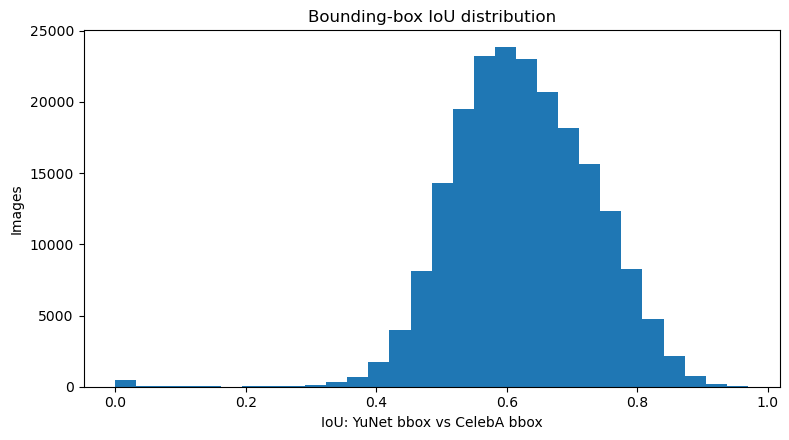

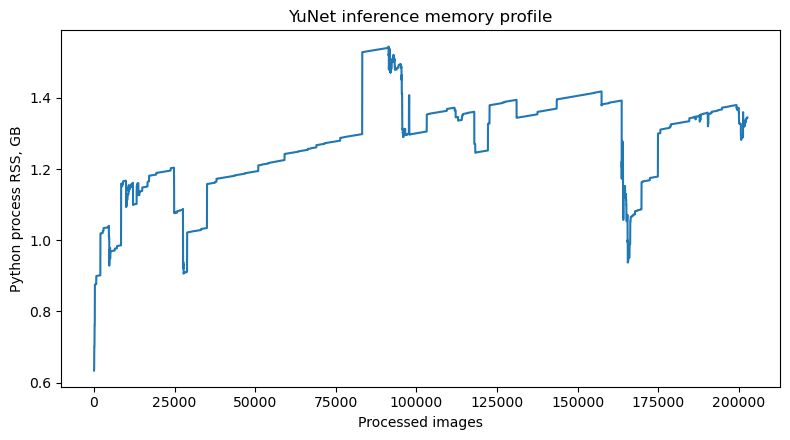

In [9]:

if len(ok):
    fig = plt.figure(figsize=(8,4.5))
    plt.hist(ok["iou"].dropna(),bins=30)
    plt.xlabel("IoU: YuNet bbox vs CelebA bbox")
    plt.ylabel("Images")
    plt.title("Bounding-box IoU distribution")
    plt.tight_layout()
    plt.savefig(OUT_ROOT/"iou_distribution.png",dpi=150)
    plt.show()
    plt.close(fig)

if len(memory_df):
    fig = plt.figure(figsize=(8,4.5))
    plt.plot(memory_df["processed_images"],memory_df["rss_gb"])
    plt.xlabel("Processed images")
    plt.ylabel("Python process RSS, GB")
    plt.title("YuNet inference memory profile")
    plt.tight_layout()
    plt.savefig(OUT_ROOT/"memory_profile.png",dpi=150)
    plt.show()
    plt.close(fig)


## Cell 10 — Random overlay collage

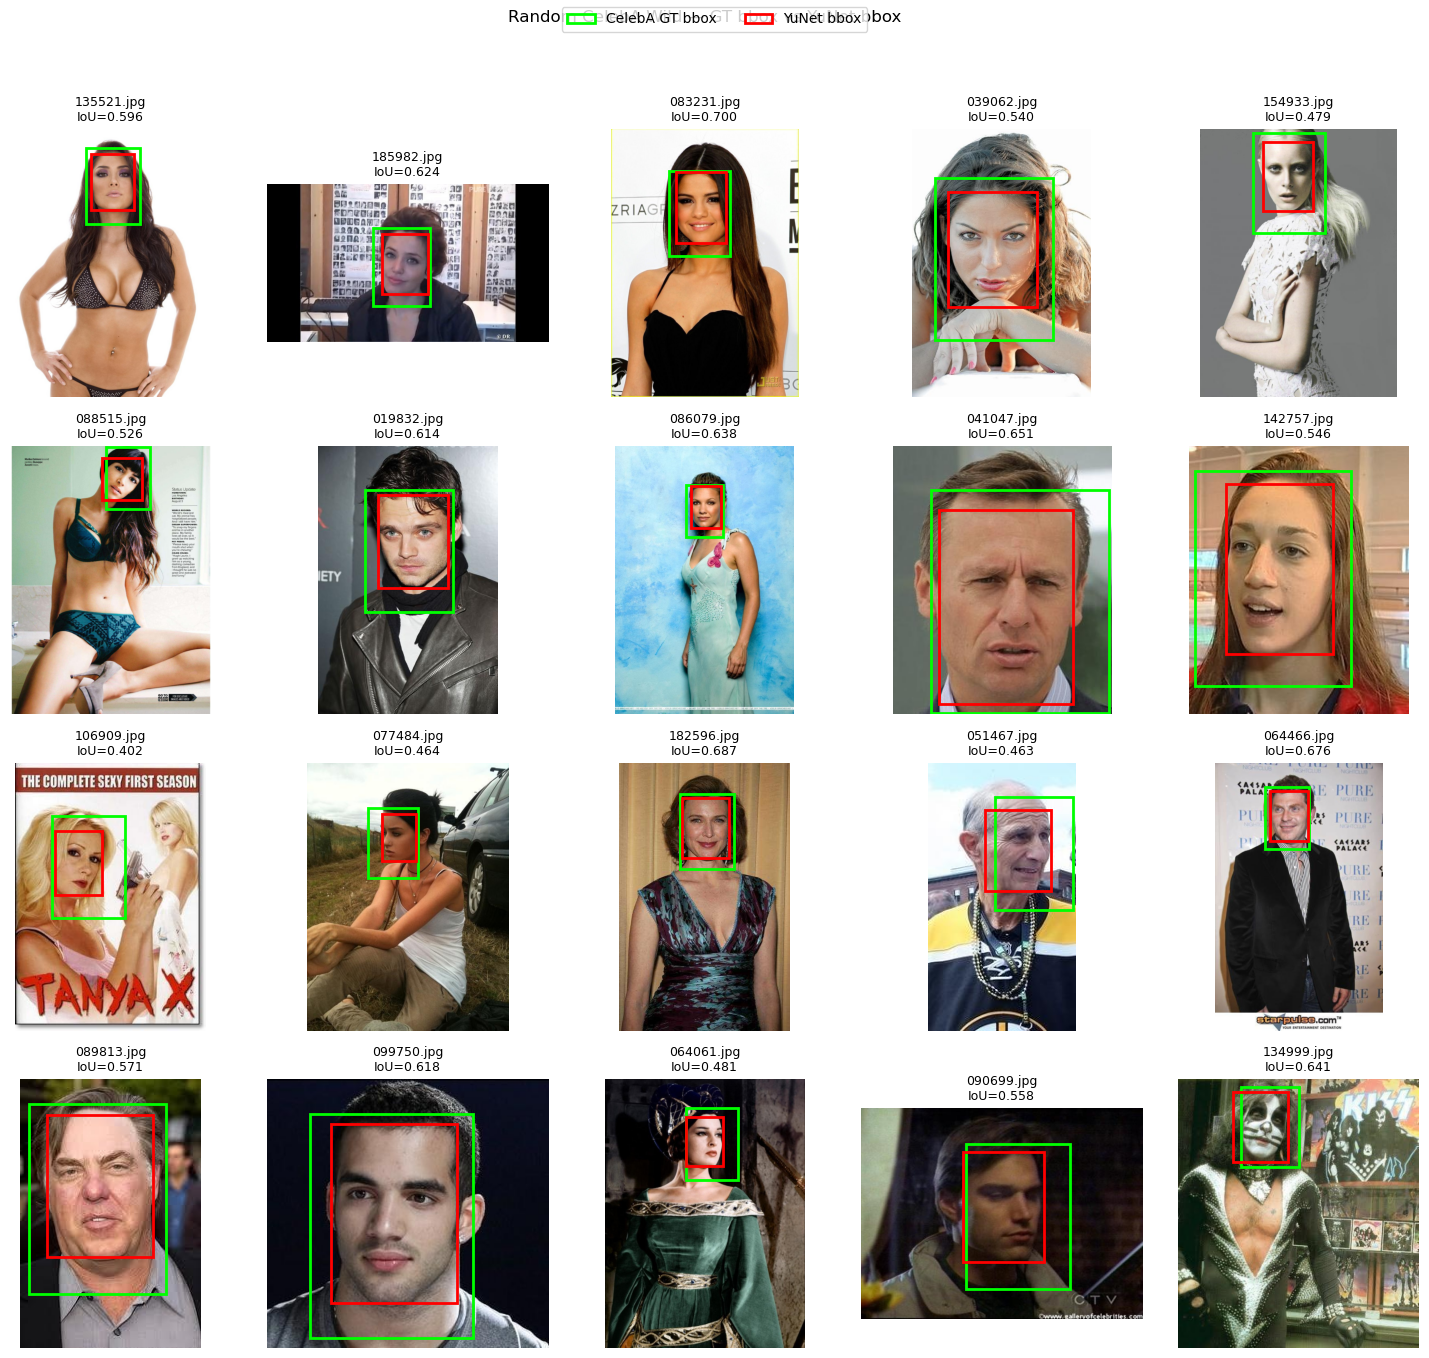

RSS after random collage, GB: 1.161


In [10]:

def draw_overlay(ax,image_id,r,max_display_side=900):
    bgr = cv2.imread(str(image_paths[image_id]))
    rgb = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
    h,w = rgb.shape[:2]
    s = min(1.0,max_display_side/max(h,w))
    if s < 1:
        rgb = cv2.resize(rgb,(round(w*s),round(h*s)),interpolation=cv2.INTER_AREA)

    ax.imshow(rgb)

    gt = np.array([r.gt_x1,r.gt_y1,r.gt_x2,r.gt_y2])*s
    pr = np.array([r.pred_x1,r.pred_y1,r.pred_x2,r.pred_y2])*s

    ax.add_patch(Rectangle((gt[0],gt[1]),gt[2]-gt[0],gt[3]-gt[1],
                           fill=False,edgecolor="lime",linewidth=2))
    ax.add_patch(Rectangle((pr[0],pr[1]),pr[2]-pr[0],pr[3]-pr[1],
                           fill=False,edgecolor="red",linewidth=2))
    ax.set_title(f"{image_id}\nIoU={r.iou:.3f}",fontsize=9)
    ax.axis("off")
    del bgr,rgb

def make_collage(frame,n,title,path,seed=None):
    if len(frame)==0: return
    n=min(n,len(frame))
    frame = frame.sample(n=n,random_state=seed) if seed is not None else frame.head(n)
    cols=5; rows_n=math.ceil(n/cols)
    fig,axes=plt.subplots(rows_n,cols,figsize=(15,3.4*rows_n),squeeze=False)
    for ax in axes.ravel(): ax.axis("off")
    for ax,r in zip(axes.ravel(),frame.itertuples(index=False)):
        draw_overlay(ax,r.image_id,r)
    fig.legend(handles=[
        Patch(facecolor="none",edgecolor="lime",linewidth=2,label="CelebA GT bbox"),
        Patch(facecolor="none",edgecolor="red",linewidth=2,label="YuNet bbox")
    ],loc="upper center",ncol=2)
    fig.suptitle(title,y=.995)
    fig.tight_layout(rect=[0,0,1,.965])
    fig.savefig(path,dpi=150,bbox_inches="tight")
    plt.show()
    plt.close(fig)
    gc.collect()

make_collage(
    ok,RANDOM_COLLAGE_N,
    "Random CelebA Wild — GT bbox vs YuNet bbox",
    OUT_ROOT/"bbox_overlay_random.png",
    seed=SEED
)
print("RSS after random collage, GB:",round(rss_gb(),3))


## Cell 11 — Worst-IoU collage and final audit

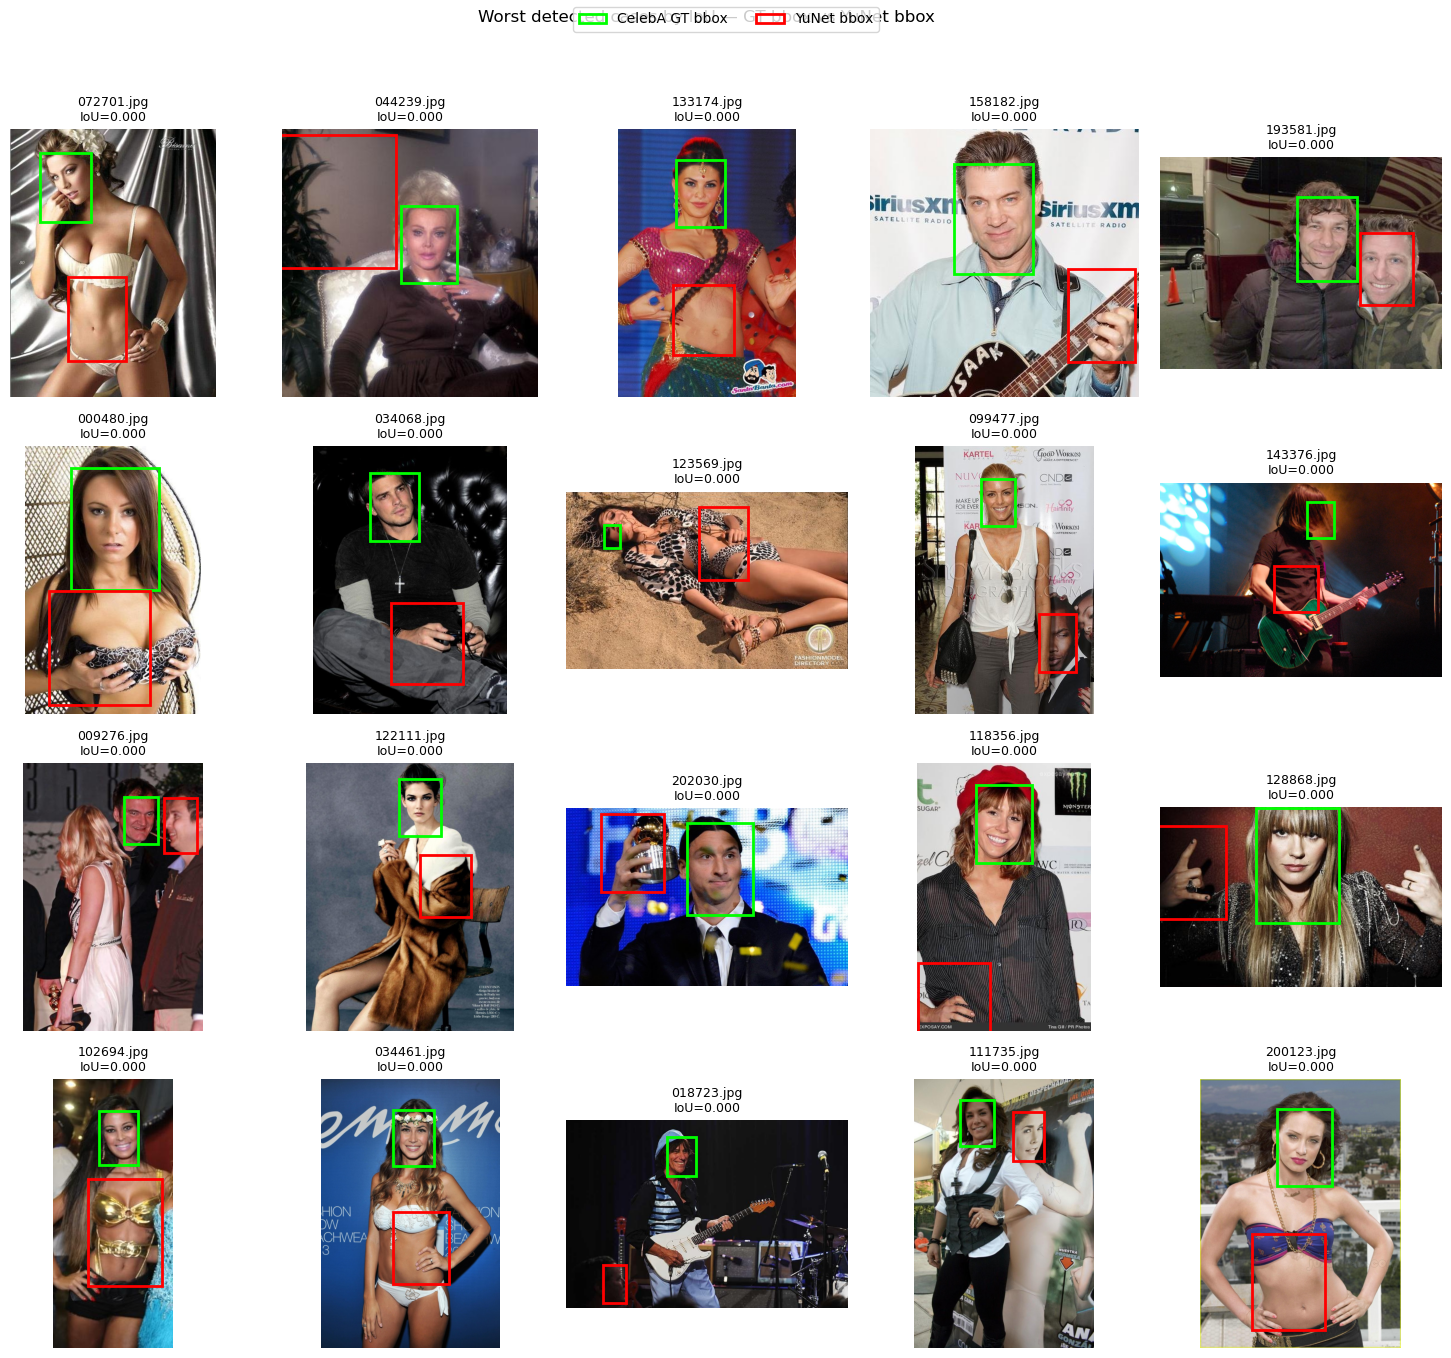

=== STATUS COUNTS ===
status
ok         202328
no_face       270
Name: count, dtype: int64

=== LOW-IoU COUNTS ===
IoU < 0.9: 202080 / 202328 (99.8774%)
IoU < 0.8: 192753 / 202328 (95.2676%)
IoU < 0.7: 152303 / 202328 (75.2753%)
IoU < 0.5: 21449 / 202328 (10.6011%)

Detected bboxes not containing all 5 GT landmarks: 1217


,image_id,iou,gt_landmarks_inside_pred_bbox,center_displacement_norm_gt_diag,area_ratio_pred_over_gt
104,000105.jpg,0.0,0.0,0.955606,0.747703
479,000480.jpg,0.0,0.0,0.799048,1.074974
597,000598.jpg,0.0,0.0,1.214354,1.784101
2595,002596.jpg,0.0,0.0,0.783863,0.703317
3412,003413.jpg,0.0,0.0,1.213549,1.416313
3730,003731.jpg,0.0,0.0,2.722575,1.450274
4921,004922.jpg,0.0,0.0,1.401432,5.960248
5573,005574.jpg,0.0,0.0,0.998893,1.085770
6204,006205.jpg,0.0,0.0,1.505839,0.858219
6868,006869.jpg,0.0,0.0,0.787676,1.835729



Final RSS, GB: 1.152
Inference RSS delta, GB: 0.914

Output files:
bbox_diagnostic_results.csv
bbox_diagnostic_summary.json
bbox_overlay_random.png
bbox_overlay_worst_iou.png
face_detection_yunet_2023mar.onnx
iou_distribution.png
memory_profile.csv
memory_profile.png


In [11]:

worst = ok.sort_values("iou",ascending=True).copy()

make_collage(
    worst,WORST_COLLAGE_N,
    "Worst detected cases by IoU — GT bbox vs YuNet bbox",
    OUT_ROOT/"bbox_overlay_worst_iou.png"
)

print("=== STATUS COUNTS ===")
print(results["status"].value_counts(dropna=False))

if len(ok):
    print("\n=== LOW-IoU COUNTS ===")
    for t in [0.9,0.8,0.7,0.5]:
        n=int((ok["iou"]<t).sum())
        print(f"IoU < {t:.1f}: {n} / {len(ok)} ({n/len(ok):.4%})")

    bad_lm = ok[
        (ok["gt_landmarks_valid"]==5) &
        (ok["gt_landmarks_inside_pred_bbox"]<5)
    ].sort_values(["gt_landmarks_inside_pred_bbox","iou"])

    print("\nDetected bboxes not containing all 5 GT landmarks:",len(bad_lm))
    if len(bad_lm):
        display(bad_lm[
            ["image_id","iou","gt_landmarks_inside_pred_bbox",
             "center_displacement_norm_gt_diag","area_ratio_pred_over_gt"]
        ].head(30))

print("\nFinal RSS, GB:",round(rss_gb(),3))
print("Inference RSS delta, GB:",round(rss_end-rss_start,3))

print("\nOutput files:")
for p in sorted(OUT_ROOT.glob("*")):
    print(p.name)



## Interpretation

Compare YuNet with the SCRFD reference using the same criteria:

1. detection rate;
2. bbox IoU / center displacement / scale ratio;
3. fraction of predicted boxes containing all five CelebA GT landmarks;
4. runtime / throughput;
5. process RSS growth;
6. random and worst-case visual overlays.

A systematic bbox-convention difference is not automatically a detector failure;
use the landmark-containment metric and visual collages together with IoU.
